# **Notebook 04: Avaliação do Modelo e Métricas**

Este notebook finaliza o pipeline de Machine Learning seguindo os princípios de MLOps. Em vez de treinar o algoritmo aqui, vamos carregar o artefato serializado (`modelo_rf_bot_detector.pkl`) e submetê-lo aos dados de teste (`X_test` e `y_test`) que foram isolados no final da etapa de pré-processamento.

O objetivo é avaliar a capacidade de generalização do modelo em dados inéditos, utilizando a Matriz de Confusão e o Relatório de Classificação para medir a eficácia real do detector de bots.

### **1. Configuração do Ambiente e Importação do Artefato**

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

# Montando o Drive
drive.mount('/content/drive')
caminho_base = '/content/drive/MyDrive/Colab_Notebooks/ml_bot_detector/'

# Carregando os dados de teste (o modelo nunca viu esses dados)
X_test = pd.read_csv(f'{caminho_base}X_test.csv')
y_test = pd.read_csv(f'{caminho_base}y_test.csv').values.ravel()

# Carregando o modelo treinado (o cérebro)
modelo_rf = joblib.load(f'{caminho_base}modelo_rf_bot_detector.pkl')

print(f"Modelo carregado: {modelo_rf}")
print(f"Dados de teste carregados: {X_test.shape[0]} amostras prontas para avaliação.")

Mounted at /content/drive
Modelo carregado: RandomForestClassifier(n_jobs=-1, random_state=42)
Dados de teste carregados: 39982 amostras prontas para avaliação.


### **2. Previsões e Matriz de Confusão**

A acurácia global pode ser uma métrica enganosa em problemas de segurança. Para um detector de bots em WordPress, precisamos avaliar os erros de forma categórica usando a **Matriz de Confusão**:

* **Falso Positivo (Erro Crítico):** Classificar um leitor/cliente humano como bot (impacta a experiência do usuário e o SEO).
* **Falso Negativo (Erro Moderado):** Deixar um bot passar pela barreira (consome recursos do servidor, mas não bloqueia usuários legítimos).

O objetivo de um bom modelo de segurança é minimizar drasticamente os Falsos Positivos.

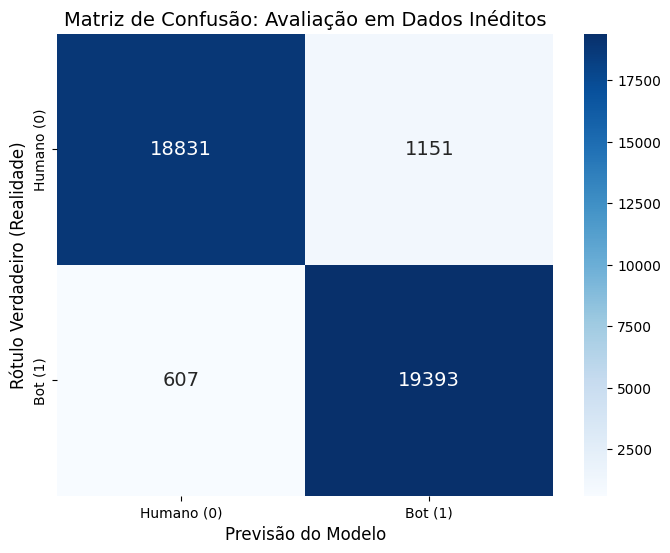

In [2]:
# Realizando as previsões com o modelo carregado
y_pred = modelo_rf.predict(X_test)

# Calculando a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Humano (0)', 'Bot (1)'],
            yticklabels=['Humano (0)', 'Bot (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusão: Avaliação em Dados Inéditos', fontsize=14)
plt.ylabel('Rótulo Verdadeiro (Realidade)', fontsize=12)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.show()

### **3. Relatório de Classificação (Precision, Recall e F1-Score)**

Para quantificar a performance visualizada na Matriz de Confusão, extraímos as métricas detalhadas:
* **Precision (Precisão):** Das requisições que o modelo bloqueou alegando ser bot, quantas realmente eram bots?
* **Recall (Revocação):** De todos os bots reais que atacaram o servidor, quantos o modelo conseguiu detectar e parar?
* **F1-Score:** A média harmônica entre Precision e Recall.

In [3]:
# Gerando o relatório de métricas
relatorio = classification_report(y_test, y_pred, target_names=['Humano (0)', 'Bot (1)'])

print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(relatorio)

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

  Humano (0)       0.97      0.94      0.96     19982
     Bot (1)       0.94      0.97      0.96     20000

    accuracy                           0.96     39982
   macro avg       0.96      0.96      0.96     39982
weighted avg       0.96      0.96      0.96     39982



### **4. Importância das Features (Feature Importance)**

Para fechar o ciclo do projeto e validar as hipóteses levantadas na etapa de Análise Exploratória (EDA), vamos extrair o peso que o algoritmo do *Random Forest* atribuiu a cada variável.

Isso nos mostra matematicamente quais características comportamentais (como acessos em horários específicos, busca por caminhos sensíveis ou consumo de extensões `.js`) foram mais decisivas para separar humanos de automações maliciosas.

/tmp/ipykernel_40008/167086734.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


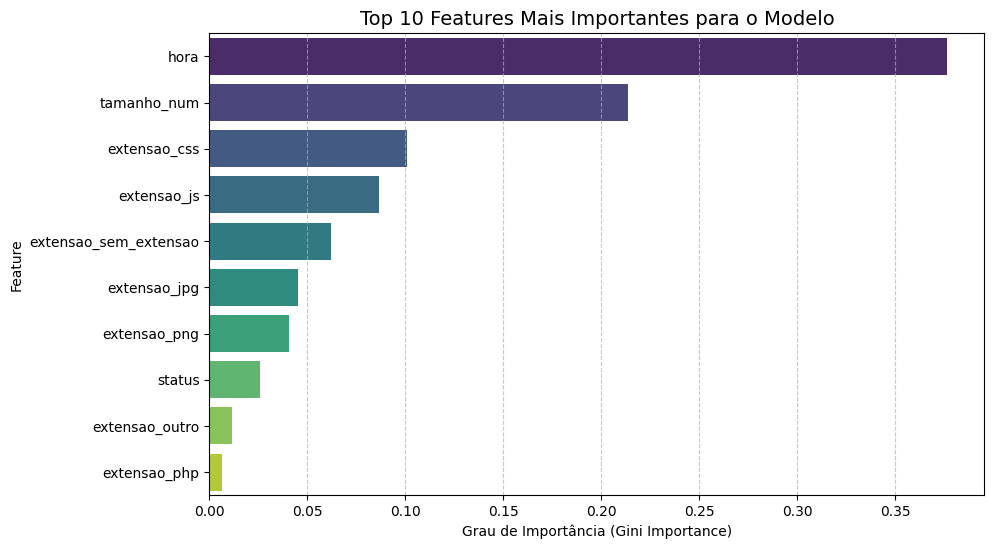

In [4]:
# Extraindo a importância de cada feature (coluna) do modelo treinado
importancias = modelo_rf.feature_importances_
features = X_test.columns

# Criando um DataFrame para facilitar a visualização e ordenando do maior para o menor
df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10) # Pegando o Top 10

# Plotando as features mais cruciais
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')

plt.title('Top 10 Features Mais Importantes para o Modelo', fontsize=14)
plt.xlabel('Grau de Importância (Gini Importance)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()